# Imports


In [49]:
import kagglehub
import os
import pandas as pd
from pathlib import Path
import torch
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv
from sklearn.metrics import classification_report

# Data

In [28]:
path = kagglehub.dataset_download("ellipticco/elliptic-data-set")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Dell\.cache\kagglehub\datasets\ellipticco\elliptic-data-set\versions\1


In [29]:
dir_path = Path(path) / "elliptic_bitcoin_dataset"

classes_path = dir_path / "elliptic_txs_classes.csv"
edgelist_path = dir_path / "elliptic_txs_edgelist.csv"
features_path = dir_path / "elliptic_txs_features.csv"

df_classes = pd.read_csv(classes_path)
df_edgelist = pd.read_csv(edgelist_path)
df_features = pd.read_csv(features_path, header=None)

In [30]:
df_classes

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown
...,...,...
203764,173077460,unknown
203765,158577750,unknown
203766,158375402,1
203767,158654197,unknown


In [31]:
df_edgelist

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206
...,...,...
234350,158365409,157930723
234351,188708874,188708879
234352,157659064,157659046
234353,87414554,106877725


In [32]:
df_features

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,173077460,49,-0.145771,-0.163752,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,-0.135803,...,-0.577099,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
203765,158577750,49,-0.165920,-0.123607,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156418,...,0.162722,0.010822,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,-1.760926,-1.760984
203766,158375402,49,-0.172014,-0.078182,1.018602,0.028105,-0.043875,0.054722,-0.061584,-0.163626,...,1.261246,1.985050,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
203767,158654197,49,-0.172842,-0.176622,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.163501,...,-0.397749,-0.411776,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,1.519700,1.521399


# Data processing

### Merge DataFrames

In [33]:
df_features.columns = ["txId", "time_step"] + [f"feature_{i}" for i in range(1, len(df_features.columns) - 1)]
df = pd.merge(df_features, df_classes, on="txId")
df

,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,173077460,49,-0.145771,-0.163752,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,-0.135803,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
203765,158577750,49,-0.165920,-0.123607,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156418,...,0.010822,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,-1.760926,-1.760984,unknown
203766,158375402,49,-0.172014,-0.078182,1.018602,0.028105,-0.043875,0.054722,-0.061584,-0.163626,...,1.985050,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,1
203767,158654197,49,-0.172842,-0.176622,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.163501,...,-0.411776,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,1.519700,1.521399,unknown


### Class mask

In [34]:
df["label"] = df["class"].map({"1": 1, "2": 0, "unknown": -1})
df["labeled_mask"] = df["label"] != -1

df

C:\Users\Dell\AppData\Local\Temp\ipykernel_14748\3987237647.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["class"].map({"1": 1, "2": 0, "unknown": -1})
C:\Users\Dell\AppData\Local\Temp\ipykernel_14748\3987237647.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["labeled_mask"] = df["label"] != -1


,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class,label,labeled_mask
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,-1,False
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,-1,False
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown,-1,False
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2,0,True
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown,-1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,173077460,49,-0.145771,-0.163752,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,-0.135803,...,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,-1,False
203765,158577750,49,-0.165920,-0.123607,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156418,...,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,-1.760926,-1.760984,unknown,-1,False
203766,158375402,49,-0.172014,-0.078182,1.018602,0.028105,-0.043875,0.054722,-0.061584,-0.163626,...,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,1,1,True
203767,158654197,49,-0.172842,-0.176622,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.163501,...,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,1.519700,1.521399,unknown,-1,False


### Converting edge ID to 0 - N-1 ragne

In [35]:
mapping = {idx: i for i, idx in enumerate(df["txId"].values)}

df_edgelist["txId1"] = df_edgelist["txId1"].map(mapping)
df_edgelist["txId2"] = df_edgelist["txId2"].map(mapping)

df_edgelist

,txId1,txId2
0,0,1
1,2,3
2,4,5
3,6,7
4,8,9
...,...,...
234350,203602,201430
234351,203603,203099
234352,201921,202042
234353,201480,201368


### Create Data Object

In [36]:
edge_index = torch.tensor(df_edgelist[["txId1", "txId2"]].values.T, dtype=torch.long)
feature_cols = [f"feature_{i}" for i in range(1, 166)]

x = torch.tensor(df[feature_cols].values, dtype=torch.float)
y = torch.tensor(df["label"].values, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)

### Train-Test Split

In [37]:
time_steps = df["time_step"].values
is_known = df["labeled_mask"].values

train_mask = (time_steps <= 34) & is_known
test_mask = (time_steps > 34) & is_known

data.train_mask = torch.tensor(train_mask, dtype=torch.bool)
data.test_mask = torch.tensor(test_mask, dtype=torch.bool)

# Data visualization

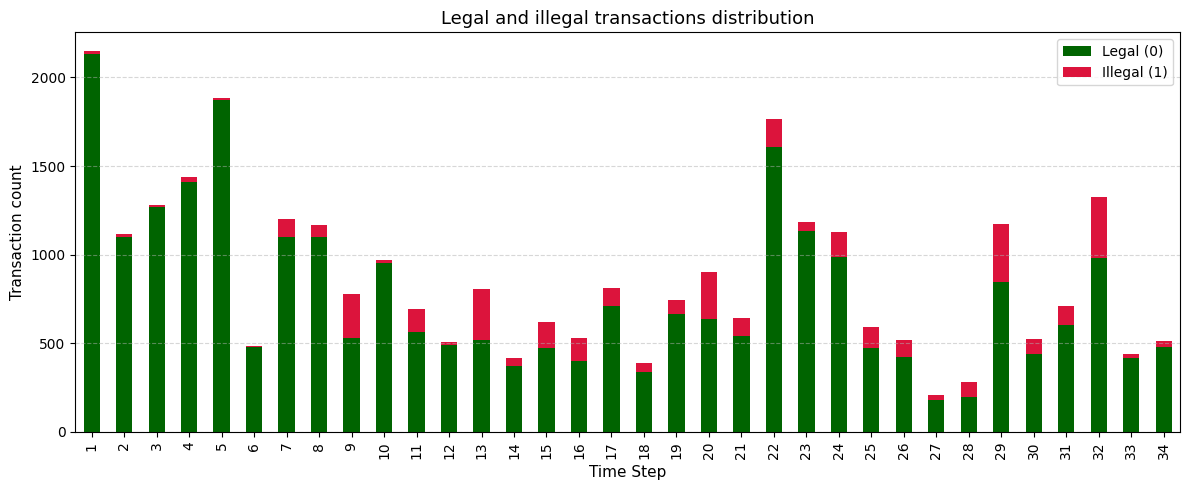

In [38]:
df_train_plot = df[(df["time_step"] <= 34) & (df["labeled_mask"] == True)]

grouped_train = df_train_plot.groupby(["time_step", "label"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
grouped_train.plot(kind="bar", stacked=True, ax=plt.gca(), color=["darkgreen", "crimson"])

plt.title("Legal and illegal transactions distribution", fontsize=13)
plt.xlabel("Time Step", fontsize=11)
plt.ylabel("Transaction count", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(["Legal (0)", "Illegal (1)"])

plt.tight_layout()
plt.show()

In [ ]:
def visualize_train_timestep(chosen_step):
    df_step = df[(df["time_step"] == chosen_step) & (df["labeled_mask"] == True)]
    step_nodes = set(df_step.index)

    df_edges_step = df_edgelist[
        df_edgelist["txId1"].isin(step_nodes) & df_edgelist["txId2"].isin(step_nodes)
    ]

    G = nx.from_pandas_edgelist(df_edges_step, source="txId1", target="txId2")
    G.add_nodes_from(step_nodes)

    color_map = []
    for node in G.nodes():
        label = df.loc[node, "label"]
        if label == 1:
            color_map.append("crimson")
        else:
            color_map.append("darkgreen")

    plt.figure(figsize=(12, 10))
    plt.title(f"Transaction Network Structure for Train Time Step {chosen_step}", fontsize=14)

    pos = nx.spring_layout(G, k=0.15, seed=42)

    nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=20, alpha=0.8)
    nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color="gray")

    plt.axis("off")
    plt.show()

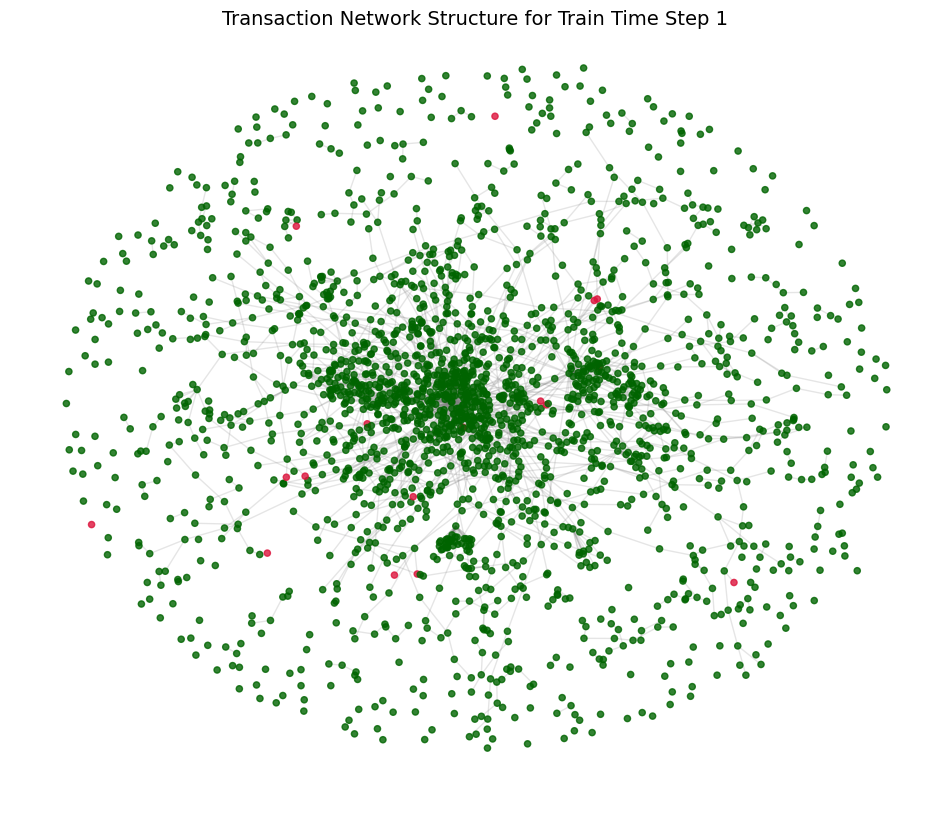

In [40]:
visualize_train_timestep(1)

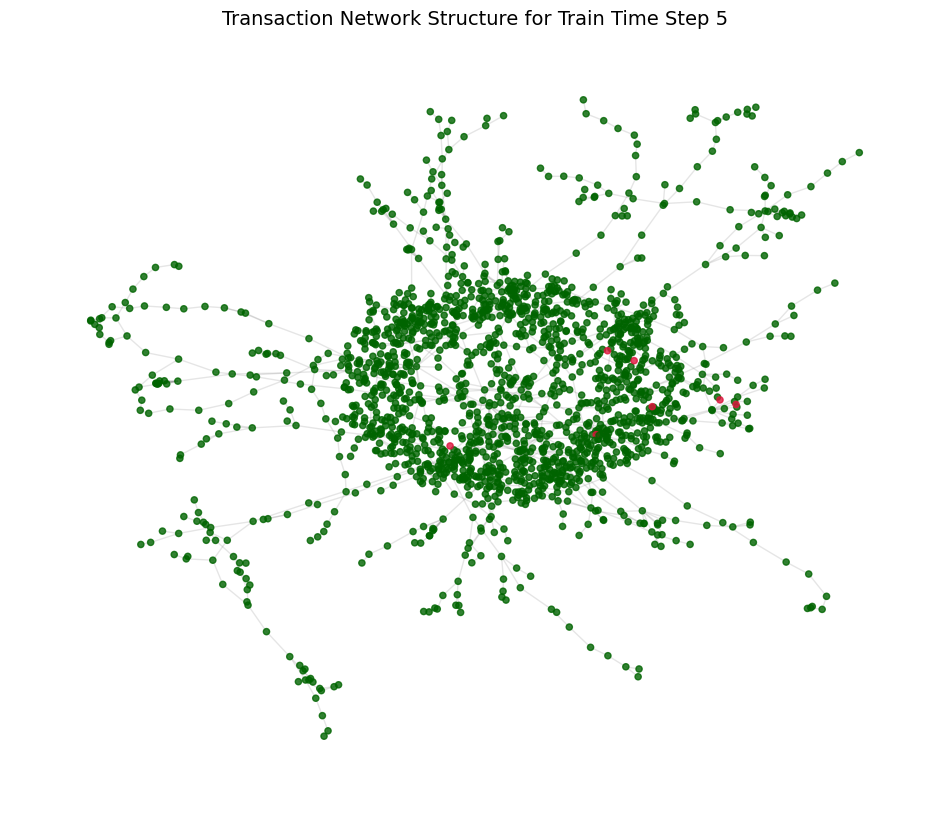

In [41]:
visualize_train_timestep(5)

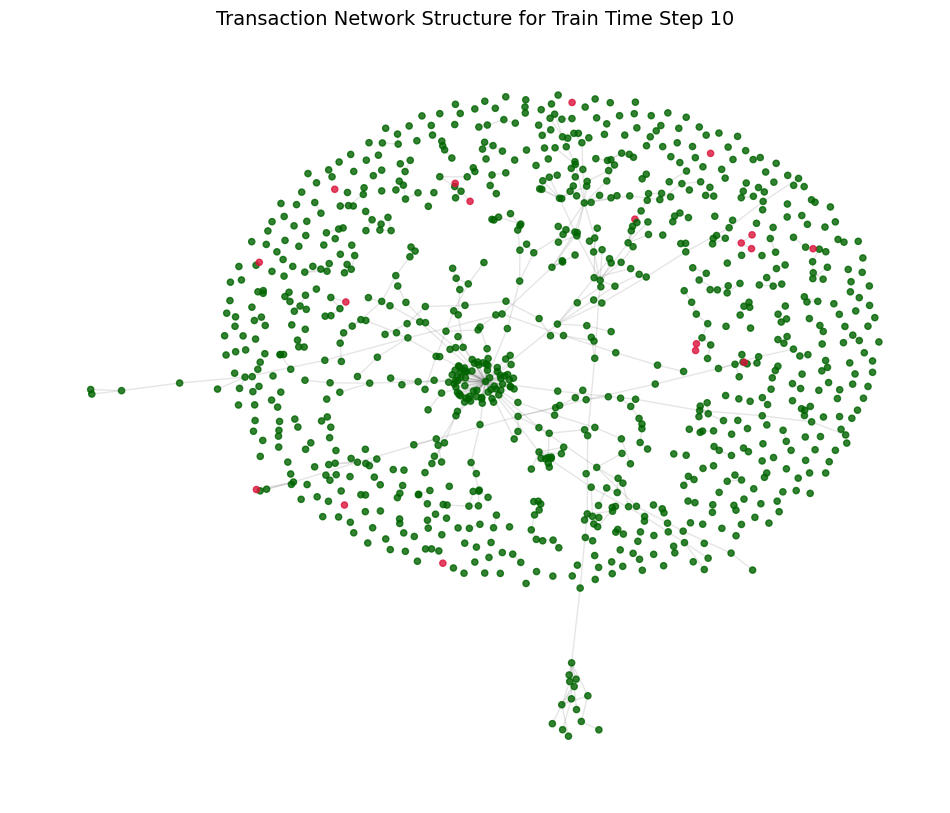

In [42]:
visualize_train_timestep(10)

# Training and evaluation

### Base

In [46]:
class BitcoinGCNStandard(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, 64)
        self.conv2 = GCNConv(64, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


class BitcoinGCNWide(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, 128)
        self.conv2 = GCNConv(128, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


class BitcoinGCNDeep(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, 64)
        self.conv2 = GCNConv(64, 64)
        self.conv3 = GCNConv(64, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

In [48]:
class BitcoinGATStandard(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super().__init__()
        self.conv1 = GATConv(num_node_features, 8, heads=8)
        self.conv2 = GATConv(8 * 8, num_classes, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


class BitcoinGATMultiHead(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super().__init__()
        self.conv1 = GATConv(num_node_features, 8, heads=16)
        self.conv2 = GATConv(8 * 16, num_classes, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


class BitcoinGATDeep(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super().__init__()
        self.conv1 = GATConv(num_node_features, 8, heads=8)
        self.conv2 = GATConv(8 * 8, 8, heads=8)
        self.conv3 = GATConv(8 * 8, num_classes, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

In [51]:
models_dict = {
    "GCN_Standard": BitcoinGCNStandard(data.num_node_features, 2),
    "GCN_Wide": BitcoinGCNWide(data.num_node_features, 2),
    "GCN_Deep": BitcoinGCNDeep(data.num_node_features, 2),
    "GAT_Standard": BitcoinGATStandard(data.num_node_features, 2),
    "GAT_MultiHead": BitcoinGATMultiHead(data.num_node_features, 2),
    "GAT_Deep": BitcoinGATDeep(data.num_node_features, 2),
}

In [52]:
train_labels = df[(df["time_step"] <= 34) & (df["labeled_mask"] == True)]["label"].values
class_counts = np.bincount(train_labels)
total_samples = len(train_labels)
class_weights = total_samples / (len(class_counts) * class_counts)
weights_tensor = torch.tensor(class_weights, dtype=torch.float)

criterion = torch.nn.CrossEntropyLoss(weight=weights_tensor, ignore_index=-1)

for model_name, model in models_dict.items():
    print(f"Training: {model_name}\n")

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

    for epoch in range(1, 101):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        if epoch % 20 == 0:
            model.eval()
            with torch.no_grad():
                out_eval = model(data)
                pred_eval = out_eval.argmax(dim=1)
                train_correct = (
                    pred_eval[data.train_mask] == data.y[data.train_mask]
                )
                train_acc = int(train_correct.sum()) / int(data.train_mask.sum())
                test_correct = pred_eval[data.test_mask] == data.y[data.test_mask]
                test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
            print(
                f"Epoch: {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}"
            )

    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out.argmax(dim=1)

    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()

    print(f"\nFinal Test Results for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=["Legal", "Illicit"]))
    print("\n")

Training: GCN_Standard

Epoch: 020, Loss: 0.3355, Train Acc: 0.8491, Test Acc: 0.6989
Epoch: 040, Loss: 0.2732, Train Acc: 0.8919, Test Acc: 0.7954
Epoch: 060, Loss: 0.2415, Train Acc: 0.9052, Test Acc: 0.8589
Epoch: 080, Loss: 0.2205, Train Acc: 0.9133, Test Acc: 0.8777
Epoch: 100, Loss: 0.2077, Train Acc: 0.9203, Test Acc: 0.8897

Final Test Results for GCN_Standard:
              precision    recall  f1-score   support

       Legal       0.97      0.91      0.94     15587
     Illicit       0.31      0.57      0.40      1083

    accuracy                           0.89     16670
   macro avg       0.64      0.74      0.67     16670
weighted avg       0.93      0.89      0.90     16670



Training: GCN_Wide

Epoch: 020, Loss: 0.3002, Train Acc: 0.8722, Test Acc: 0.6889
Epoch: 040, Loss: 0.2362, Train Acc: 0.9046, Test Acc: 0.8501
Epoch: 060, Loss: 0.2033, Train Acc: 0.9199, Test Acc: 0.8960
Epoch: 080, Loss: 0.1815, Train Acc: 0.9291, Test Acc: 0.9080
Epoch: 100, Loss: 0.1715, Train

GAT models perform better than GCN ones. All of them have f-1 score of above 0.5. The best model is GATMultiHead with f-1 score of 0.59.

### Optimizer modifications

In [53]:
model_opt = BitcoinGATMultiHead(data.num_node_features, 2)

optimizer_opt = torch.optim.AdamW(model_opt.parameters(), lr=0.01, weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_opt, mode='min', factor=0.5, patience=10)

for epoch in range(1, 101):
    model_opt.train()
    optimizer_opt.zero_grad()
    out = model_opt(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer_opt.step()
    
    scheduler.step(loss)
    
    if epoch % 20 == 0:
        model_opt.eval()
        with torch.no_grad():
            out_eval = model_opt(data)
            pred_eval = out_eval.argmax(dim=1)
            test_correct = pred_eval[data.test_mask] == data.y[data.test_mask]
            test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
        print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}, LR: {optimizer_opt.param_groups[0]['lr']:.5f}, Test Acc: {test_acc:.4f}")

model_opt.eval()
with torch.no_grad():
    y_pred = model_opt(data).argmax(dim=1)[data.test_mask].cpu().numpy()
    y_true = data.y[data.test_mask].cpu().numpy()
    print("\nFinal Optimized Results:")
    print(classification_report(y_true, y_pred, target_names=["Legal", "Illicit"]))

c:\Users\Dell\Desktop\Studia\3 Rok\GGSN\Laby\Mini-Projekty\Bitcoin_Transaction_ML\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:1691: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  current = float(metrics)


Epoch: 020, Loss: 0.2658, LR: 0.01000, Test Acc: 0.6967
Epoch: 040, Loss: 0.1891, LR: 0.01000, Test Acc: 0.8526
Epoch: 060, Loss: 0.1522, LR: 0.01000, Test Acc: 0.9159
Epoch: 080, Loss: 0.1223, LR: 0.01000, Test Acc: 0.9296
Epoch: 100, Loss: 0.1104, LR: 0.01000, Test Acc: 0.9369

Final Optimized Results:
              precision    recall  f1-score   support

       Legal       0.97      0.96      0.97     15587
     Illicit       0.51      0.57      0.54      1083

    accuracy                           0.94     16670
   macro avg       0.74      0.77      0.75     16670
weighted avg       0.94      0.94      0.94     16670



In [54]:
model_opt = BitcoinGATMultiHead(data.num_node_features, 2)

optimizer_opt = torch.optim.AdamW(model_opt.parameters(), lr=0.05, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_opt, mode='min', factor=0.5, patience=10)

for epoch in range(1, 101):
    model_opt.train()
    optimizer_opt.zero_grad()
    out = model_opt(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer_opt.step()
    
    scheduler.step(loss)
    
    if epoch % 20 == 0:
        model_opt.eval()
        with torch.no_grad():
            out_eval = model_opt(data)
            pred_eval = out_eval.argmax(dim=1)
            test_correct = pred_eval[data.test_mask] == data.y[data.test_mask]
            test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
        print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}, LR: {optimizer_opt.param_groups[0]['lr']:.5f}, Test Acc: {test_acc:.4f}")

model_opt.eval()
with torch.no_grad():
    y_pred = model_opt(data).argmax(dim=1)[data.test_mask].cpu().numpy()
    y_true = data.y[data.test_mask].cpu().numpy()
    print("\nFinal Optimized Results:")
    print(classification_report(y_true, y_pred, target_names=["Legal", "Illicit"]))

Epoch: 020, Loss: 0.3000, LR: 0.05000, Test Acc: 0.8959
Epoch: 040, Loss: 0.1957, LR: 0.05000, Test Acc: 0.9139
Epoch: 060, Loss: 0.1478, LR: 0.05000, Test Acc: 0.9215
Epoch: 080, Loss: 0.1303, LR: 0.05000, Test Acc: 0.9329
Epoch: 100, Loss: 0.1161, LR: 0.05000, Test Acc: 0.9335

Final Optimized Results:
              precision    recall  f1-score   support

       Legal       0.97      0.96      0.96     15587
     Illicit       0.49      0.51      0.50      1083

    accuracy                           0.93     16670
   macro avg       0.73      0.74      0.73     16670
weighted avg       0.93      0.93      0.93     16670



In [55]:
model_opt = BitcoinGATMultiHead(data.num_node_features, 2)

optimizer_opt = torch.optim.AdamW(model_opt.parameters(), lr=0.005, weight_decay=5e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_opt, mode='min', factor=0.5, patience=10)

for epoch in range(1, 101):
    model_opt.train()
    optimizer_opt.zero_grad()
    out = model_opt(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer_opt.step()
    
    scheduler.step(loss)
    
    if epoch % 20 == 0:
        model_opt.eval()
        with torch.no_grad():
            out_eval = model_opt(data)
            pred_eval = out_eval.argmax(dim=1)
            test_correct = pred_eval[data.test_mask] == data.y[data.test_mask]
            test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
        print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}, LR: {optimizer_opt.param_groups[0]['lr']:.5f}, Test Acc: {test_acc:.4f}")

model_opt.eval()
with torch.no_grad():
    y_pred = model_opt(data).argmax(dim=1)[data.test_mask].cpu().numpy()
    y_true = data.y[data.test_mask].cpu().numpy()
    print("\nFinal Optimized Results:")
    print(classification_report(y_true, y_pred, target_names=["Legal", "Illicit"]))

Epoch: 020, Loss: 0.2851, LR: 0.00500, Test Acc: 0.7167
Epoch: 040, Loss: 0.2081, LR: 0.00500, Test Acc: 0.8194
Epoch: 060, Loss: 0.1718, LR: 0.00500, Test Acc: 0.8801
Epoch: 080, Loss: 0.1510, LR: 0.00500, Test Acc: 0.9089
Epoch: 100, Loss: 0.1314, LR: 0.00500, Test Acc: 0.9232

Final Optimized Results:
              precision    recall  f1-score   support

       Legal       0.98      0.94      0.96     15587
     Illicit       0.44      0.65      0.53      1083

    accuracy                           0.92     16670
   macro avg       0.71      0.80      0.74     16670
weighted avg       0.94      0.92      0.93     16670



In [56]:
model_opt = BitcoinGATMultiHead(data.num_node_features, 2)

optimizer_opt = torch.optim.Adam(model_opt.parameters(), lr=0.05, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_opt, mode='min', factor=0.5, patience=10)

for epoch in range(1, 101):
    model_opt.train()
    optimizer_opt.zero_grad()
    out = model_opt(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer_opt.step()
    
    scheduler.step(loss)
    
    if epoch % 20 == 0:
        model_opt.eval()
        with torch.no_grad():
            out_eval = model_opt(data)
            pred_eval = out_eval.argmax(dim=1)
            test_correct = pred_eval[data.test_mask] == data.y[data.test_mask]
            test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
        print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}, LR: {optimizer_opt.param_groups[0]['lr']:.5f}, Test Acc: {test_acc:.4f}")

model_opt.eval()
with torch.no_grad():
    y_pred = model_opt(data).argmax(dim=1)[data.test_mask].cpu().numpy()
    y_true = data.y[data.test_mask].cpu().numpy()
    print("\nFinal Optimized Results:")
    print(classification_report(y_true, y_pred, target_names=["Legal", "Illicit"]))

Epoch: 020, Loss: 0.2968, LR: 0.05000, Test Acc: 0.7997
Epoch: 040, Loss: 0.1871, LR: 0.05000, Test Acc: 0.8990
Epoch: 060, Loss: 0.1491, LR: 0.05000, Test Acc: 0.9395
Epoch: 080, Loss: 0.1283, LR: 0.05000, Test Acc: 0.9502
Epoch: 100, Loss: 0.1145, LR: 0.05000, Test Acc: 0.9543

Final Optimized Results:
              precision    recall  f1-score   support

       Legal       0.97      0.98      0.98     15587
     Illicit       0.69      0.53      0.60      1083

    accuracy                           0.95     16670
   macro avg       0.83      0.76      0.79     16670
weighted avg       0.95      0.95      0.95     16670



In [57]:
model_opt = BitcoinGATMultiHead(data.num_node_features, 2)

optimizer_opt = torch.optim.Adam(model_opt.parameters(), lr=0.005, weight_decay=5e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_opt, mode='min', factor=0.5, patience=10)

for epoch in range(1, 101):
    model_opt.train()
    optimizer_opt.zero_grad()
    out = model_opt(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer_opt.step()
    
    scheduler.step(loss)
    
    if epoch % 20 == 0:
        model_opt.eval()
        with torch.no_grad():
            out_eval = model_opt(data)
            pred_eval = out_eval.argmax(dim=1)
            test_correct = pred_eval[data.test_mask] == data.y[data.test_mask]
            test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
        print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}, LR: {optimizer_opt.param_groups[0]['lr']:.5f}, Test Acc: {test_acc:.4f}")

model_opt.eval()
with torch.no_grad():
    y_pred = model_opt(data).argmax(dim=1)[data.test_mask].cpu().numpy()
    y_true = data.y[data.test_mask].cpu().numpy()
    print("\nFinal Optimized Results:")
    print(classification_report(y_true, y_pred, target_names=["Legal", "Illicit"]))

Epoch: 020, Loss: 0.3085, LR: 0.00500, Test Acc: 0.6454
Epoch: 040, Loss: 0.2258, LR: 0.00500, Test Acc: 0.7806
Epoch: 060, Loss: 0.1827, LR: 0.00500, Test Acc: 0.8449
Epoch: 080, Loss: 0.1556, LR: 0.00500, Test Acc: 0.8897
Epoch: 100, Loss: 0.1328, LR: 0.00500, Test Acc: 0.9219

Final Optimized Results:
              precision    recall  f1-score   support

       Legal       0.98      0.94      0.96     15587
     Illicit       0.43      0.66      0.52      1083

    accuracy                           0.92     16670
   macro avg       0.70      0.80      0.74     16670
weighted avg       0.94      0.92      0.93     16670



Using learning rate of 0.05 and weight_decay of 1e-5 slightly improved the model (f1-score of 0.60).